# Necessary Imports for the Notebook

The examples in this notebook require the following imports.
Make sure to run this cell before any other cell.




In [1]:
pip install skfeature-chappers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 1.3 MB/s eta 0:00:00


In [2]:
pip install nanopq

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from nanopq import PQ  # Make sure you have nanopq installed: pip install nanopq
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
from skfeature.function.information_theoretical_based import CMIM, JMI
import gc
import time
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score

In [4]:
import scipy.spatial as ss
from scipy.special import digamma
from math import log
import numpy.random as nr
import numpy as np
import random
def hist(sx):
    # Histogram from list of samples
    d = dict()
    for s in sx:
        d[s] = d.get(s, 0) + 1

    return map(lambda z: float(z)/len(sx), d.values())

def elog(x):
    # for entropy, 0 log 0 = 0. but we get an error for putting log 0
    if x <= 0. or x >= 1.:
        return 0
    else:
        return x*log(x)

def cmidd(x, y, z):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return entropyd(list(zip(y, z)))+entropyd(list(zip(x, z)))-entropyd(list(zip(x, y, z)))-entropyd(z)

# Discrete estimators
def entropyd(sx, base=2):
    """
    Discrete entropy estimator given a list of samples which can be any hashable object
    """

    return entropyfromprobs(hist(sx), base=base)

def entropyfromprobs(probs, base=2):
    # Turn a normalized list of probabilities of discrete outcomes into entropy (base 2)
    return -sum(map(elog, probs))/log(base)

def midd(x, y):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return -entropyd(list(zip(x, y)))+entropyd(x)+entropyd(y)

In [5]:
import numpy as np
from math import log

def hist(sx):
    # Histogram from list of samples
    d = dict()
    for s in sx:
        d[s] = d.get(s, 0) + 1

    return map(lambda z: float(z)/len(sx), d.values())

def elog(x):
    # for entropy, 0 log 0 = 0. but we get an error for putting log 0
    if x <= 0. or x >= 1.:
        return 0
    else:
        return x*log(x)

def cmidd(x, y, z):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return entropyd(list(zip(y, z)))+entropyd(list(zip(x, z)))-entropyd(list(zip(x, y, z)))-entropyd(z)

# Discrete estimators
def entropyd(sx, base=2):
    """
    Discrete entropy estimator given a list of samples which can be any hashable object
    """

    return entropyfromprobs(hist(sx), base=base)

def entropyfromprobs(probs, base=2):
    # Turn a normalized list of probabilities of discrete outcomes into entropy (base 2)
    return -sum(map(elog, probs))/log(base)

def midd(x, y):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return -entropyd(list(zip(x, y)))+entropyd(x)+entropyd(y)

def fast_cmim(X, y, **kwargs):
    """
    This function implements the CMIM feature selection.
    Input
    -----
    X: {numpy array}, shape (n_samples, n_features)
        Input data, guaranteed to be a discrete numpy array
    y: {numpy array}, shape (n_samples,)
        guaranteed to be a numpy array
    kwargs: {dictionary}
        n_selected_features: {int}
            number of features to select
    Output
    ------
    F: {numpy array}, shape (n_features,)
        index of selected features, F[0] is the most important feature
    t1: {numpy array}, shape: (n_features,)
        minimal corresponding mutual information between selected features and response when
        conditionned on a previously selected feature
    Reference
    ---------
    Fleuret 2004 - Fast Binary Feature Selection with Conditional Mutual Information
    http://www.idiap.ch/~fleuret/papers/fleuret-jmlr2004.pdf
    """

    n_samples, n_features = X.shape
    is_n_selected_features_specified = False

    if 'n_selected_features' in kwargs.keys():
        n_selected_features = kwargs['n_selected_features']
        is_n_selected_features_specified = True
        F = np.nan * np.zeros(n_selected_features)
    else:
        F = np.nan * np.zeros(n_features)

    # t1
    t1 = np.zeros(n_features)

    # m is a counting indicator
    m = np.zeros(n_features) - 1

    for i in range(n_features):
        f = X[:, i]
        t1[i] = midd(f, y)


    for k in range(n_features):
        ### uncomment to keep track
        # counter = int(np.sum(~np.isnan(F)))
        # if counter%5 == 0 or counter <= 1:
        #     print("F contains %s features"%(counter))
        if k == 0:
            # select the feature whose mutual information is the largest
            idx = np.argmax(t1)
            F[0] = idx
            f_select = X[:, idx]

        if is_n_selected_features_specified:
            if np.sum(~np.isnan(F)) == n_selected_features:
                break

        sstar = -1000000 # start with really low value for best partial score sstar
        for i in range(n_features):

            if i not in F:

                while (t1[i] > sstar) and (m[i]<k-1) :
                    m[i] = m[i] + 1
                    t1[i] = min(t1[i], cmidd(X[:,i], # feature i
                                             y,  # target
                                             X[:, int(F[int(m[i])])] # conditionned on selected features
                                            )
                               )
                if t1[i] > sstar:
                    sstar = t1[i]
                    F[k+1] = i

    F = np.array(F[F>-100])
    F = F.astype(int)
    t1 = t1[F]
    return (F, t1)

# **Reading CSV file**

In [6]:
# Load data
data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
#data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-CIC-2020.csv")
X = data.iloc[:, :-1].values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)

In [ ]:
data

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Class
0,0,0,0,0,0,0,0,0,0,1,...,1,1,1,0,0,0,0,0,1,1
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,1
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,0,1,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7125,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7126,0,0,0,1,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7127,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7128,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

In [ ]:
# record start time
start = time.time()
f, t = fast_cmim(X_train,y_train, n_selected_features = 100)
end = time.time()

# print the difference between start
# and end time in milli. secs
print("The time of execution of above program is :",
      (end-start), "sec")

The time of execution of above program is : 69.36624336242676 sec


In [ ]:
f

array([149,  86, 220, 228, 233, 152, 100, 163, 191, 229, 235, 237, 217,
       219, 218, 216, 236, 200, 225, 138, 182, 190, 223, 231, 221, 226,
        15,  62,   9, 214,  30,  74, 234, 137, 196, 119,  64,  76, 187,
       158, 232, 240, 230, 215,   5,   3,   4, 154,  19, 204,  25, 188,
       208,   7, 110, 238,  98, 141, 125,  47, 222,  59,  55, 239,  22,
       129,  44, 156, 209, 111, 205, 145,  54,  70,  80, 165, 155,  60,
       176, 150, 224, 212, 167,  63,  77, 112,   0,   6,  66, 107,  43,
       175,  78, 140, 114,  18,  72,  94, 171,  26])

In [7]:
f = [149,  86, 220, 228, 233, 152, 100, 163, 191, 229, 235, 237, 217,
       219, 218, 216, 236, 200, 225, 138, 182, 190, 223, 231, 221, 226,
        15,  62,   9, 214,  30,  74, 234, 137, 196, 119,  64,  76, 187,
       158, 232, 240, 230, 215,   5,   3,   4, 154,  19, 204,  25, 188,
       208,   7, 110, 238,  98, 141, 125,  47, 222,  59,  55, 239,  22,
       129,  44, 156, 209, 111, 205, 145,  54,  70,  80, 165, 155,  60,
       176, 150, 224, 212, 167,  63,  77, 112,   0,   6,  66, 107,  43,
       175,  78, 140, 114,  18,  72,  94, 171,  26]

In [9]:
f = np.array(f)
f

array([149,  86, 220, 228, 233, 152, 100, 163, 191, 229, 235, 237, 217,
       219, 218, 216, 236, 200, 225, 138, 182, 190, 223, 231, 221, 226,
        15,  62,   9, 214,  30,  74, 234, 137, 196, 119,  64,  76, 187,
       158, 232, 240, 230, 215,   5,   3,   4, 154,  19, 204,  25, 188,
       208,   7, 110, 238,  98, 141, 125,  47, 222,  59,  55, 239,  22,
       129,  44, 156, 209, 111, 205, 145,  54,  70,  80, 165, 155,  60,
       176, 150, 224, 212, 167,  63,  77, 112,   0,   6,  66, 107,  43,
       175,  78, 140, 114,  18,  72,  94, 171,  26])

In [8]:
selected_features_names=[]
for i in range(len(f)):
    selected_features_names.append(data.columns[f[i]])
selected_features_names

['RECEIVE_BOOT_COMPLETED',
 'GET_TASKS',
 'Ljava/net/URL;->openConnection',
 'Landroid/location/LocationManager;->getLastKgoodwarewnLocation',
 'Landroid/telephony/TelephonyManager;->getNetworkOperator',
 'RECEIVE_SMS',
 'KILL_BACKGROUND_PROCESSES',
 'SEND_SMS',
 'WAKE_LOCK',
 'Landroid/telephony/TelephonyManager;->getDeviceId',
 'Landroid/telephony/TelephonyManager;->getNetworkCountryIso',
 'Landroid/telephony/TelephonyManager;->getSimOperatorName',
 'Ljava/lang/System;->load',
 'Ljava/lang/System;->loadLibrary',
 'Ldalvik/system/DexClassLoader;->loadClass',
 'Ljava/lang/Runtime;->exec',
 'Landroid/telephony/TelephonyManager;->getSimOperator',
 'WRITE_EXTERNAL_STORAGE',
 'Landroid/media/AudioRecord;->startRecording',
 'READ_PHONE_STATE',
 'SYSTEM_ALERT_WINDOW',
 'VIBRATE',
 'Landroid/telephony/SmsManager;->sendMultipartTextMessage',
 'Landroid/content/pm/PackageManager;->getInstalledPackages',
 'Landroid/hardware/Camera;->open',
 'Landroid/telephony/TelephonyManager;->getCellLocation'

In [10]:
len(selected_features_names)

100

# find the highest accuracy with respect to different number of features

In [11]:
lr={
    "acc":{"index":[],"val":[],},
    "per":{"index":[],"val":[],},
    "rec":{"index":[],"val":[],},
    "f1s":{"index":[],"val":[],},
    "auc":{"index":[],"val":[],},
}

data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
for i in range(2,len(selected_features_names)+1,2):
    X = data[selected_features_names[:i]].values  # Features
    y = data.iloc[:, -1].values   # Binary labels (0 or 1)
    start = time.time()
    pq_pq = PQ(M=int(i/2), Ks=2)
    pq_pq.fit(X.astype(np.float32))
    codes_pq = pq_pq.encode(X.astype(np.float32))
    end = time.time()

    # print the difference between start
    # and end time in milli. secs
    print("The time of execution of above program is :",
          (end-start), "sec")
    X_train, X_test, y_train, y_test = train_test_split(codes_pq,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

    # Initialize a classifier
    lr_model = LogisticRegression(random_state=2, solver='liblinear')
    start = time.time()
    lr_model.fit(X_train, y_train)
    end = time.time()
    print("The time of execution of training the tabpfn is :",
          (end-start), "sec")
    # Predict labels
    start = time.time()
    y_pred = lr_model.predict(X_test)
    end = time.time()
    print("The time of execution of testing sample with the tabpfn is :",
          ((end-start)/len(X_test)), "sec")
    lr["acc"]['val'].append(accuracy_score(y_test, y_pred))
    lr["acc"]['index'].append(i)
    lr["per"]['val'].append(precision_score(y_test, y_pred))
    lr["per"]['index'].append(i)
    lr["rec"]['val'].append(recall_score(y_test, y_pred))
    lr["rec"]['index'].append(i)
    lr["f1s"]['val'].append(f1_score(y_test, y_pred))
    lr["f1s"]['index'].append(i)

    y_prob = lr_model.predict_proba(X_test)  # Get probability scores for ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    lr["auc"]['val'].append(auc(fpr, tpr))
    lr["auc"]['index'].append(i)

M: 1, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 1
Encoding the subspace: 0 / 1
The time of execution of above program is : 0.030840635299682617 sec
The time of execution of training the tabpfn is : 0.00955510139465332 sec
The time of execution of testing sample with the tabpfn is : 3.3020806011611916e-07 sec
M: 2, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 2
Training the subspace: 1 / 2
Encoding the subspace: 0 / 2
Encoding the subspace: 1 / 2
The time of execution of above program is : 0.018419504165649414 sec
The time of execution of training the tabpfn is : 0.006880283355712891 sec
The time of execution of testing sample with the tabpfn is : 3.425804127483181e-07 sec
M: 3, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 3
Training the subspace: 1 / 3
Training the subspace: 2 / 3
Encoding the subspace: 0 / 3
Encoding

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


Training the subspace: 1 / 4
Training the subspace: 2 / 4
Training the subspace: 3 / 4
Encoding the subspace: 0 / 4
Encoding the subspace: 1 / 4
Encoding the subspace: 2 / 4
Encoding the subspace: 3 / 4
The time of execution of above program is : 0.08183836936950684 sec
The time of execution of training the tabpfn is : 0.012323141098022461 sec
The time of execution of testing sample with the tabpfn is : 2.6149134482106853e-07 sec
M: 5, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 5
Training the subspace: 1 / 5
Training the subspace: 2 / 5
Training the subspace: 3 / 5
Training the subspace: 4 / 5
Encoding the subspace: 0 / 5
Encoding the subspace: 1 / 5
Encoding the subspace: 2 / 5
Encoding the subspace: 3 / 5
Encoding the subspace: 4 / 5
The time of execution of above program is : 0.05085253715515137 sec
The time of execution of training the tabpfn is : 0.010178804397583008 sec
The time of execution of testing sample with the tabp

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


Training the subspace: 5 / 6
Encoding the subspace: 0 / 6
Encoding the subspace: 1 / 6
Encoding the subspace: 2 / 6
Encoding the subspace: 3 / 6
Encoding the subspace: 4 / 6
Encoding the subspace: 5 / 6
The time of execution of above program is : 0.06305265426635742 sec
The time of execution of training the tabpfn is : 0.023016691207885742 sec
The time of execution of testing sample with the tabpfn is : 2.4694547078051037e-07 sec
M: 7, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 7
Training the subspace: 1 / 7
Training the subspace: 2 / 7
Training the subspace: 3 / 7
Training the subspace: 4 / 7
Training the subspace: 5 / 7
Training the subspace: 6 / 7
Encoding the subspace: 0 / 7
Encoding the subspace: 1 / 7
Encoding the subspace: 2 / 7
Encoding the subspace: 3 / 7
Encoding the subspace: 4 / 7
Encoding the subspace: 5 / 7
Encoding the subspace: 6 / 7
The time of execution of above program is : 0.10250234603881836 sec
The time of 

...

Training the subspace: 27 / 48
Training the subspace: 28 / 48
Training the subspace: 29 / 48
Training the subspace: 30 / 48
Training the subspace: 31 / 48
Training the subspace: 32 / 48
Training the subspace: 33 / 48
Training the subspace: 34 / 48
Training the subspace: 35 / 48
Training the subspace: 36 / 48
Training the subspace: 37 / 48
Training the subspace: 38 / 48
Training the subspace: 39 / 48
Training the subspace: 40 / 48
Training the subspace: 41 / 48
Training the subspace: 42 / 48
Training the subspace: 43 / 48
Training the subspace: 44 / 48
Training the subspace: 45 / 48
Training the subspace: 46 / 48
Training the subspace: 47 / 48
Encoding the subspace: 0 / 48
Encoding the subspace: 1 / 48
Encoding the subspace: 2 / 48
Encoding the subspace: 3 / 48
Encoding the subspace: 4 / 48
Encoding the subspace: 5 / 48
Encoding the subspace: 6 / 48
Encoding the subspace: 7 / 48
Encoding the subspace: 8 / 48
Encoding the subspace: 9 / 48
Encoding the subspace: 10 / 48
Encoding the subsp

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


Training the subspace: 8 / 49
Training the subspace: 9 / 49
Training the subspace: 10 / 49
Training the subspace: 11 / 49
Training the subspace: 12 / 49
Training the subspace: 13 / 49
Training the subspace: 14 / 49
Training the subspace: 15 / 49
Training the subspace: 16 / 49
Training the subspace: 17 / 49
Training the subspace: 18 / 49
Training the subspace: 19 / 49
Training the subspace: 20 / 49
Training the subspace: 21 / 49
Training the subspace: 22 / 49
Training the subspace: 23 / 49
Training the subspace: 24 / 49
Training the subspace: 25 / 49
Training the subspace: 26 / 49
Training the subspace: 27 / 49
Training the subspace: 28 / 49
Training the subspace: 29 / 49
Training the subspace: 30 / 49
Training the subspace: 31 / 49
Training the subspace: 32 / 49
Training the subspace: 33 / 49
Training the subspace: 34 / 49
Training the subspace: 35 / 49
Training the subspace: 36 / 49
Training the subspace: 37 / 49
Training the subspace: 38 / 49
Training the subspace: 39 / 49
Training t

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


Training the subspace: 39 / 50
Training the subspace: 40 / 50
Training the subspace: 41 / 50
Training the subspace: 42 / 50
Training the subspace: 43 / 50
Training the subspace: 44 / 50
Training the subspace: 45 / 50
Training the subspace: 46 / 50
Training the subspace: 47 / 50
Training the subspace: 48 / 50
Training the subspace: 49 / 50
Encoding the subspace: 0 / 50
Encoding the subspace: 1 / 50
Encoding the subspace: 2 / 50
Encoding the subspace: 3 / 50
Encoding the subspace: 4 / 50
Encoding the subspace: 5 / 50
Encoding the subspace: 6 / 50
Encoding the subspace: 7 / 50
Encoding the subspace: 8 / 50
Encoding the subspace: 9 / 50
Encoding the subspace: 10 / 50
Encoding the subspace: 11 / 50
Encoding the subspace: 12 / 50
Encoding the subspace: 13 / 50
Encoding the subspace: 14 / 50
Encoding the subspace: 15 / 50
Encoding the subspace: 16 / 50
Encoding the subspace: 17 / 50
Encoding the subspace: 18 / 50
Encoding the subspace: 19 / 50
Encoding the subspace: 20 / 50
Encoding the subsp

In [12]:
print("the highest accuracy where the number of features is: ", lr["acc"]['index'][lr["acc"]['val'].index(max(lr["acc"]['val']))])
print("the highest accuracy value is: ", lr["acc"]['val'][lr["acc"]['val'].index(max(lr["acc"]['val']))])
print("the highest AUC where the number of features is: ", lr["auc"]['index'][lr["auc"]['val'].index(max(lr["auc"]['val']))])
print("the highest AUC value is: ", lr["auc"]['val'][lr["auc"]['val'].index(max(lr["auc"]['val']))])
print("the highest precision where the number of features is: ", lr["per"]['index'][lr["per"]['val'].index(max(lr['per']['val']))])
print("the highest precision value is: ", lr["per"]['val'][lr["per"]['val'].index(max(lr['per']['val']))])
print("the highest recall where the number of features is: ", lr["rec"]['index'][lr["rec"]['val'].index(max(lr["rec"]['val']))])
print("the highest recall value is: ", lr["rec"]['val'][lr["rec"]['val'].index(max(lr["rec"]['val']))])
print("the highest f1_score where the number of features is: ", lr["f1s"]['index'][lr["f1s"]['val'].index(max(lr["f1s"]['val']))])
print("the highest f1_score value is: ", lr["f1s"]['val'][lr["f1s"]['val'].index(max(lr["f1s"]['val']))])

the highest accuracy where the number of features is:  94
the highest accuracy value is:  0.9740532959326789
the highest AUC where the number of features is:  92
the highest AUC value is:  0.9958975922574553
the highest precision where the number of features is:  4
the highest precision value is:  0.9962546816479401
the highest recall where the number of features is:  58
the highest recall value is:  0.9692737430167597
the highest f1_score where the number of features is:  94
the highest f1_score value is:  0.9738145789101204


In [13]:
lr["auc"]['val'][lr["acc"]['val'].index(max(lr["acc"]['val']))]

np.float64(0.9958818553780786)

In [14]:
lr['acc']['val'][46] #94 features

0.9740532959326789

In [15]:
lr['acc']['val'][45] #92 features

0.9726507713884993

In [16]:
lr['auc']['val'][46] #94 features

np.float64(0.9958818553780786)

In [17]:
lr['auc']['val'][45] #92 features

np.float64(0.9958975922574553)

In [18]:
lr['per']['val'][46] #94 features

0.9870875179340028

In [19]:
lr['per']['val'][45] #92 features

0.9842632331902719

In [20]:
lr['rec']['val'][46] #94 features

0.9608938547486033

In [21]:
lr['rec']['val'][45] #92 features

0.9608938547486033

In [22]:
lr['f1s']['val'][46] #94 features

0.9738145789101204

In [23]:
lr['f1s']['val'][45] #92 features

0.9724381625441696

In [24]:
lr

{'acc': {'index': [2,
   4,
   6,
   8,
   10,
   12,
   14,
   16,
   18,
   20,
   22,
   24,
   26,
   28,
   30,
   32,
   34,
   36,
   38,
   40,
   42,
   44,
   46,
   48,
   50,
   52,
   54,
   56,
   58,
   60,
   62,
   64,
   66,
   68,
   70,
   72,
   74,
   76,
   78,
   80,
   82,
   84,
   86,
   88,
   90,
   92,
   94,
   96,
   98,
   100],
  'val': [0.8513323983169705,
   0.8695652173913043,
   0.8751753155680224,
   0.8716690042075736,
   0.8884992987377279,
   0.8906030855539971,
   0.896914446002805,
   0.8983169705469846,
   0.9172510518934082,
   0.9572230014025246,
   0.9579242636746143,
   0.9579242636746143,
   0.9593267882187938,
   0.9614305750350631,
   0.9607293127629734,
   0.9593267882187938,
   0.9621318373071529,
   0.9621318373071529,
   0.9621318373071529,
   0.9621318373071529,
   0.9614305750350631,
   0.9621318373071529,
   0.9649368863955119,
   0.9642356241234221,
   0.9642356241234221,
   0.9649368863955119,
   0.9670406732117812,
   0.9677

In [25]:
lr['acc']['val']

[0.8513323983169705,
 0.8695652173913043,
 0.8751753155680224,
 0.8716690042075736,
 0.8884992987377279,
 0.8906030855539971,
 0.896914446002805,
 0.8983169705469846,
 0.9172510518934082,
 0.9572230014025246,
 0.9579242636746143,
 0.9579242636746143,
 0.9593267882187938,
 0.9614305750350631,
 0.9607293127629734,
 0.9593267882187938,
 0.9621318373071529,
 0.9621318373071529,
 0.9621318373071529,
 0.9621318373071529,
 0.9614305750350631,
 0.9621318373071529,
 0.9649368863955119,
 0.9642356241234221,
 0.9642356241234221,
 0.9649368863955119,
 0.9670406732117812,
 0.967741935483871,
 0.97054698457223,
 0.9719495091164095,
 0.9649368863955119,
 0.9691444600280504,
 0.967741935483871,
 0.967741935483871,
 0.9684431977559608,
 0.9684431977559608,
 0.9684431977559608,
 0.9684431977559608,
 0.9691444600280504,
 0.9691444600280504,
 0.97054698457223,
 0.97054698457223,
 0.9698457223001402,
 0.9698457223001402,
 0.9726507713884993,
 0.9726507713884993,
 0.9740532959326789,
 0.9740532959326789,
 0

In [26]:
lr["rec"]['val']

[0.7653631284916201,
 0.7430167597765364,
 0.7597765363128491,
 0.7667597765363129,
 0.8184357541899442,
 0.8226256983240223,
 0.8254189944134078,
 0.8282122905027933,
 0.9231843575418994,
 0.9608938547486033,
 0.9608938547486033,
 0.9594972067039106,
 0.9594972067039106,
 0.9594972067039106,
 0.9594972067039106,
 0.9594972067039106,
 0.9594972067039106,
 0.9594972067039106,
 0.9594972067039106,
 0.9594972067039106,
 0.9594972067039106,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9594972067039106,
 0.9608938547486033,
 0.9692737430167597,
 0.9692737430167597,
 0.9608938547486033,
 0.9692737430167597,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547486033,
 0.9608938547

In [27]:
accuracy_lr = pd.DataFrame(lr['acc']['val'], index=lr['acc']['index'])
Precision_lr = pd.DataFrame(lr['per']['val'], index=lr['per']['index'])
Recall_lr = pd.DataFrame(lr['rec']['val'], index=lr['rec']['index'])
f1Score_lr = pd.DataFrame(lr['f1s']['val'], index=lr['f1s']['index'])
auc_lr = pd.DataFrame(lr['auc']['val'], index=lr['auc']['index'])

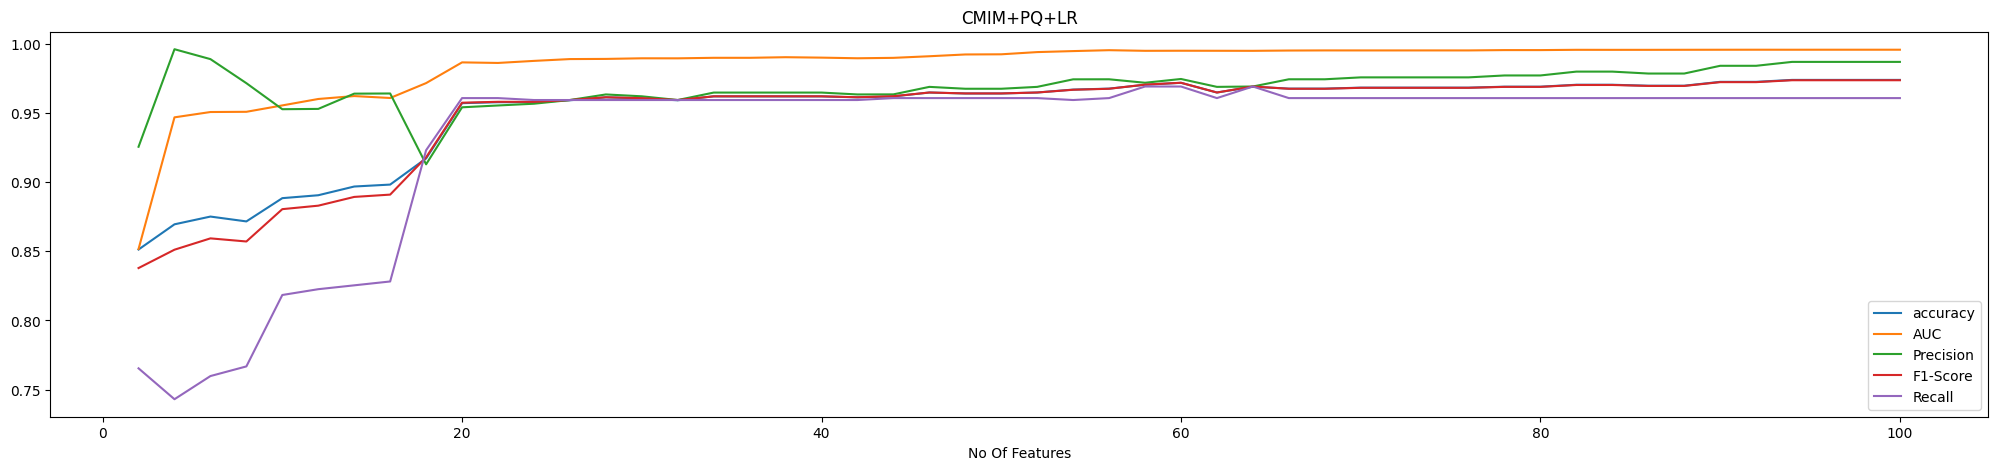

In [28]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_lr, label="accuracy")
plt.plot(auc_lr, label="AUC")
plt.plot(Precision_lr, label="Precision")
plt.plot(f1Score_lr, label="F1-Score")
plt.plot(Recall_lr , label="Recall")

plt.title("CMIM+PQ+LR")
plt.xlabel("No Of Features")
plt.ylabel("")
plt.legend()
plt.show()

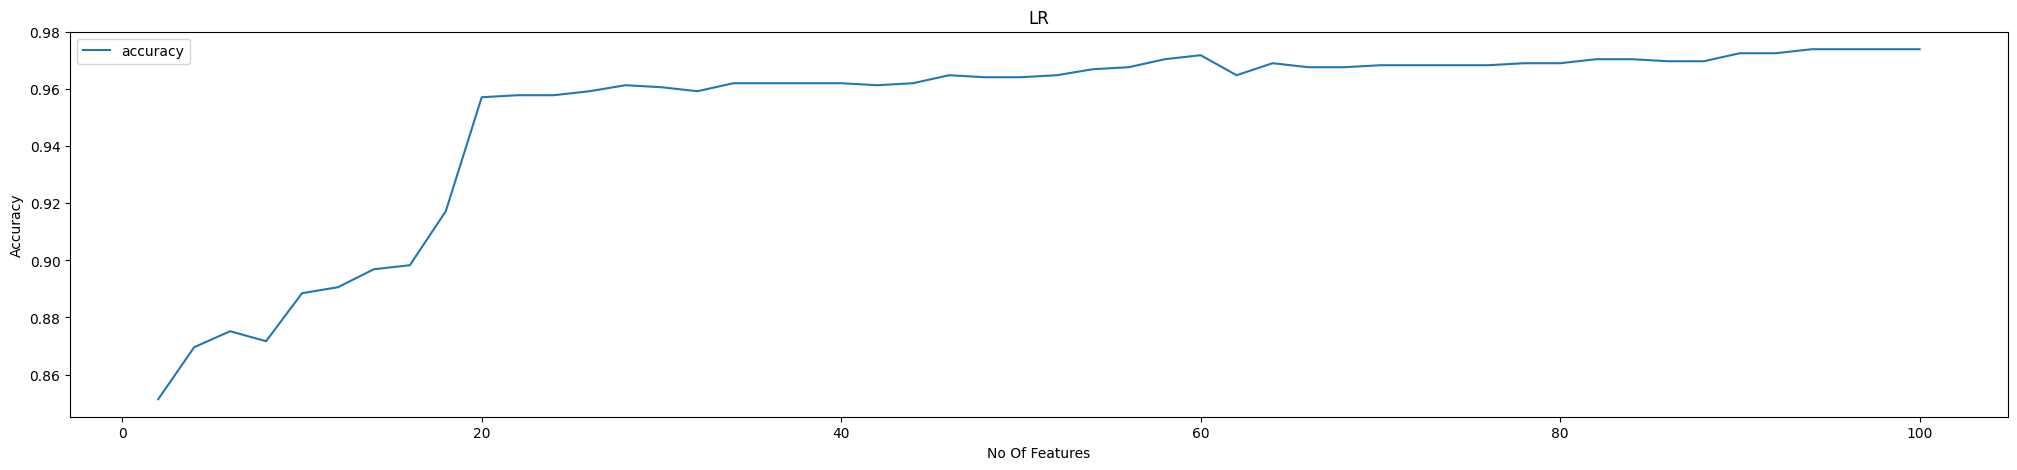

In [29]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_lr, label="accuracy")

plt.title("LR")
plt.xlabel("No Of Features")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

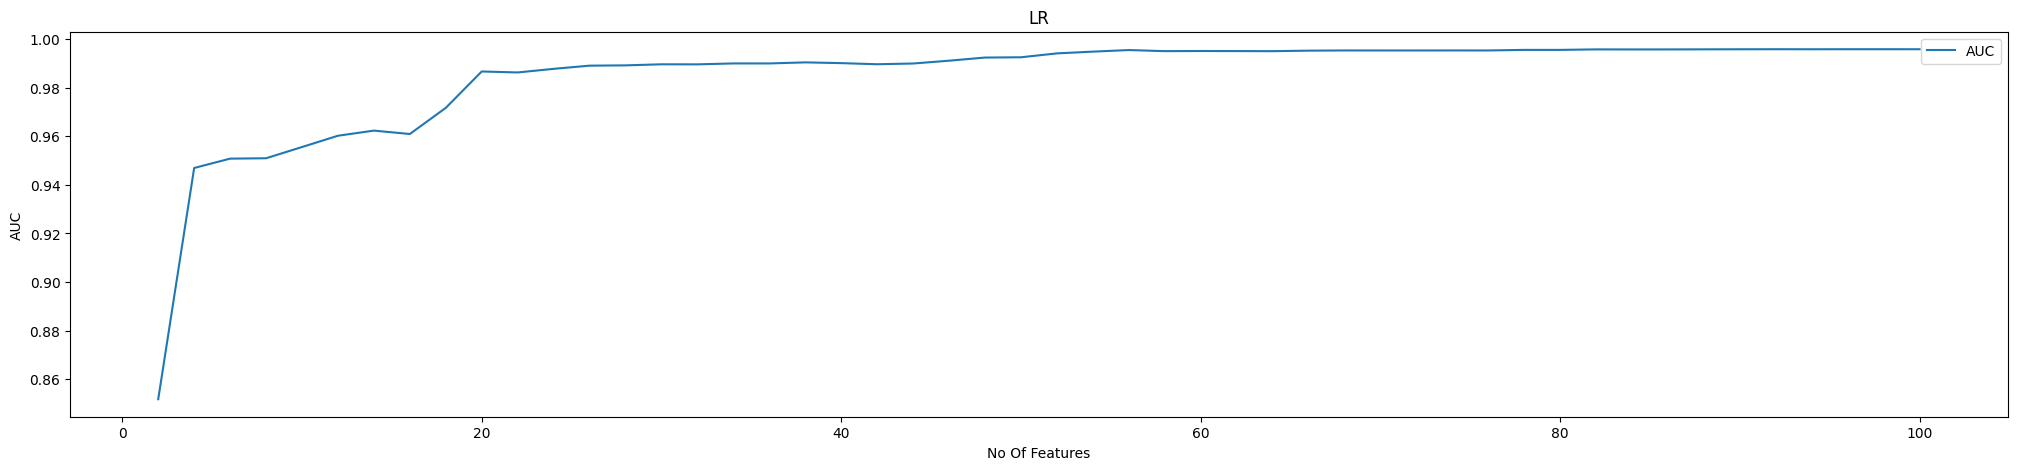

In [30]:
plt.figure(figsize=(25,5))
plt.plot(auc_lr, label="AUC")

plt.title("LR")
plt.xlabel("No Of Features")
plt.ylabel("AUC")
plt.legend()
plt.show()

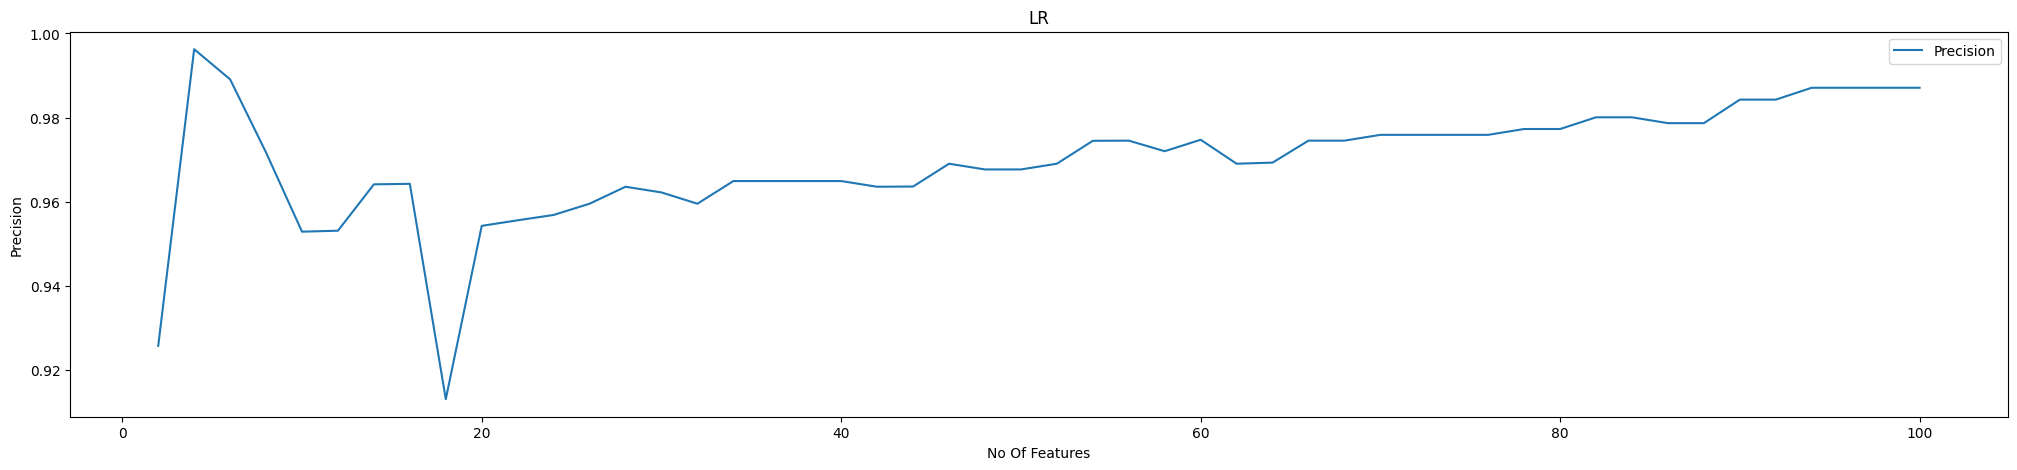

In [31]:
plt.figure(figsize=(25,5))
plt.plot(Precision_lr, label="Precision")

plt.title("LR")
plt.xlabel("No Of Features")
plt.ylabel("Precision")
plt.legend()
plt.show()

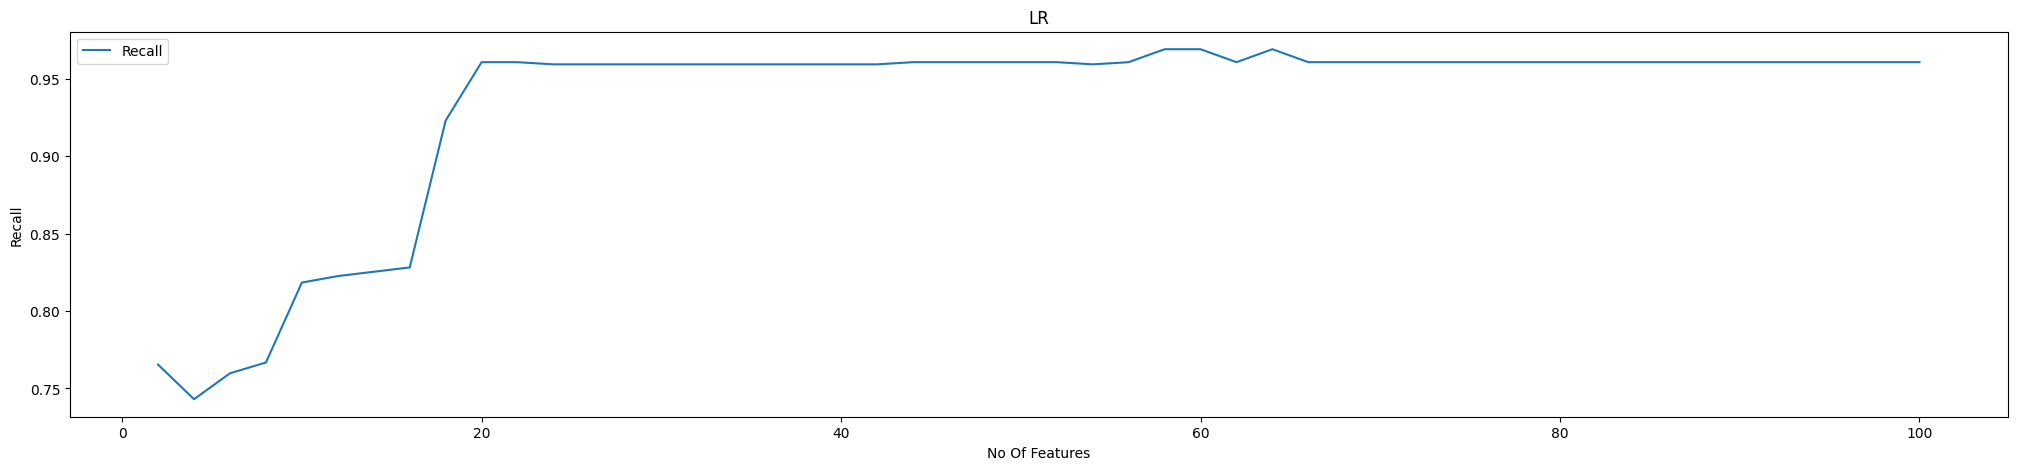

In [32]:
plt.figure(figsize=(25,5))
plt.plot(Recall_lr , label="Recall")

plt.title("LR")
plt.xlabel("No Of Features")
plt.ylabel("Recall")
plt.legend()
plt.show()

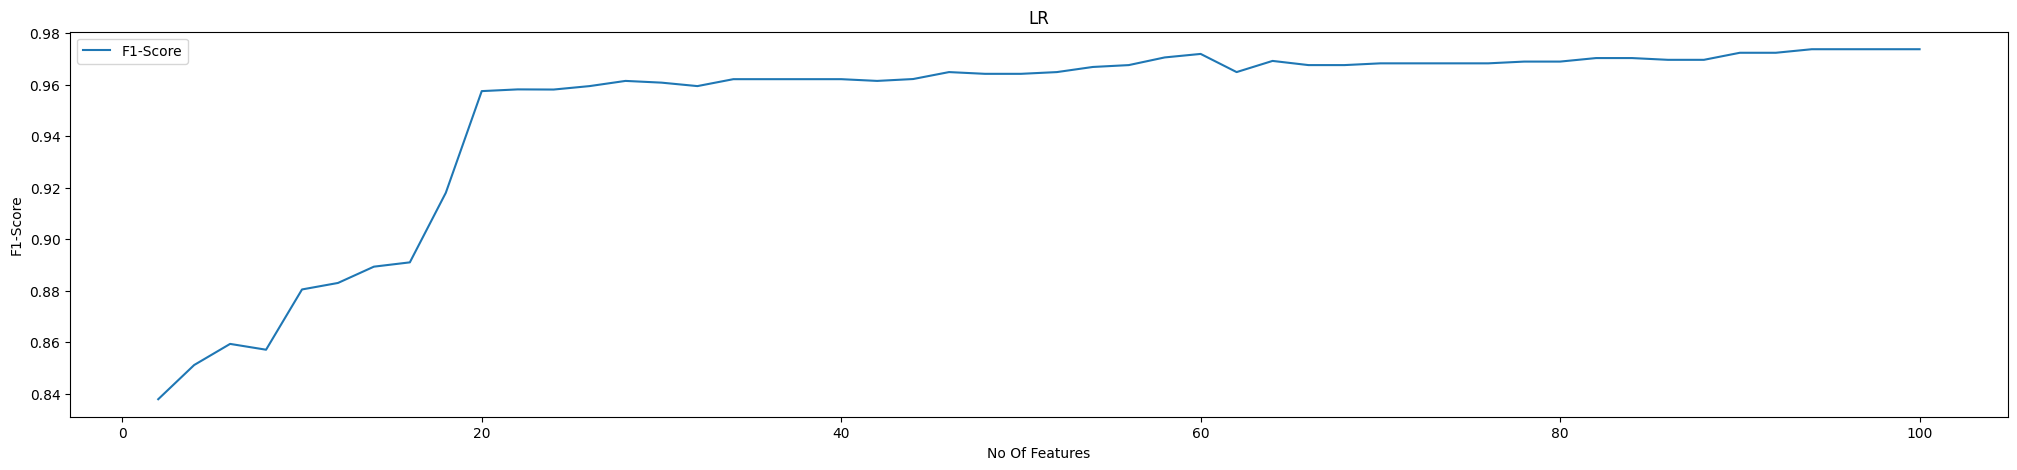

In [33]:
plt.figure(figsize=(25,5))
plt.plot(f1Score_lr, label="F1-Score")

plt.title("LR")
plt.xlabel("No Of Features")
plt.ylabel("F1-Score")
plt.legend()
plt.show()